# Analysis of Cursor Movement basic reaching und maybe continuous

In [26]:
import pandas as pd
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

# Creation of Data Frame

# Basic Reaching

In [27]:
basis_ordner = Path("data/Basic_reaching")
alle_dfs = []

#Mapping aus der fparams_copy.py
blob_mapping = {
    0: 0.15,
    1: 0.3,
    2: 0.45,
    3: 0.6
}

for datei_pfad in basis_ordner.rglob("*.csv"):
    df_temp = pd.read_csv(datei_pfad)
    
    # 1. Probanden-ID
    df_temp['Participant'] = datei_pfad.parent.name
    
    # 2. Ist es Training?
    df_temp['is_training'] = 'block_0' in datei_pfad.name
    
    # Blocknummer aus Dateinamen extrahieren (z.B. 'block_0' → 0, 'block_-1' → -1)
    block_str = datei_pfad.name.split('block_')[1].split('_')[0]
    block = int(block_str)
    df_temp['block'] = block
    
    # Blob Width zuordnen; für Practice (block=-1) wird None gesetzt
    df_temp['blob_width'] = blob_mapping.get(block, None)
    
    # Practice kennzeichnen (block == -1)
    df_temp['is_training'] = (block == -1)
    
    alle_dfs.append(df_temp)

# Zusammenführen
df_reaching = pd.concat(alle_dfs, ignore_index=True)

# Training filtern
df_reaching_clean = df_reaching[df_reaching['is_training'] == False]

# Kurzer Check, ob unsere Rekonstruktion geklappt hat!
print("Teilnehmer (einheitlich groß):", df_reaching_clean['Participant'].unique())
print("Anzahl Zeilen (ohne Practice):", len(df_reaching_clean))
print("Blöcke und zugehörige blob_width:")
print(df_reaching_clean.groupby('block')['blob_width'].unique())

Teilnehmer (einheitlich groß): ['CH51' 'IR31' 'LJ25' 'PF13']
Anzahl Zeilen (ohne Practice): 233238
Blöcke und zugehörige blob_width:
block
0    [0.15]
1     [0.3]
2    [0.45]
3     [0.6]
Name: blob_width, dtype: object


C:\Users\march\AppData\Local\Temp\ipykernel_11328\3148254975.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_reaching = pd.concat(alle_dfs, ignore_index=True)


## Daten glätten um spünge der cursor daten zu verhindern (Butterworth filter)

In [28]:
# Schritt 2: Glättung der Positionsdaten (gleitender Mittelwert)
# Zuerst sicherstellen, dass die Daten chronologisch sortiert sind
df_reaching_clean = df_reaching_clean.sort_values(['Participant', 'trial', 'time'])

# Gleitenden Mittelwert mit Fenster=5 anwenden (pro Teilnehmer und Trial)
# center=True sorgt dafür, dass der geglättete Wert in der Mitte des Fensters liegt
df_reaching_clean['cursor_x_smooth'] = (
    df_reaching_clean.groupby(['Participant', 'trial'])['cursor_x_pix']
    .rolling(window=5, center=True, min_periods=1)
    .mean()
    .reset_index(level=[0, 1], drop=True)  # Entfernt den Gruppen-Index, damit er zum DataFrame passt
)

df_reaching_clean['cursor_y_smooth'] = (
    df_reaching_clean.groupby(['Participant', 'trial'])['cursor_y_pix']
    .rolling(window=5, center=True, min_periods=1)
    .mean()
    .reset_index(level=[0, 1], drop=True)
)

# Kurzer Check: Zeige die ersten 10 Zeilen im Vergleich
print("Vergleich rohe vs. geglättete Positionen (erste 10 Zeilen):")
print(df_reaching_clean[['cursor_x_pix', 'cursor_x_smooth', 'cursor_y_pix', 'cursor_y_smooth']].head(10))
print("\nFehlen NaN-Werte in den Smooth-Spalten?", df_reaching_clean['cursor_x_smooth'].isna().sum() == 0)

Vergleich rohe vs. geglättete Positionen (erste 10 Zeilen):
      cursor_x_pix  cursor_x_smooth  cursor_y_pix  cursor_y_smooth
3157         496.0            496.0         -36.0            -36.0
3158         496.0            496.0         -36.0            -36.0
3159         496.0            496.0         -36.0            -36.0
3160         496.0            496.0         -36.0            -36.0
3161         496.0            496.0         -36.0            -36.0
3162         496.0            496.0         -36.0            -36.0
3163         496.0            496.0         -36.0            -36.0
3164         496.0            496.0         -36.0            -36.0
3165         496.0            496.0         -36.0            -36.0
3166         496.0            496.0         -36.0            -36.0

Fehlen NaN-Werte in den Smooth-Spalten? True


In [29]:
# Prüft, ob die Glättung jemals die Werte verändert hat
x_changed = (df_reaching_clean['cursor_x_smooth'] != df_reaching_clean['cursor_x_pix']).any()
y_changed = (df_reaching_clean['cursor_y_smooth'] != df_reaching_clean['cursor_y_pix']).any()

if x_changed or y_changed:
    print("Glättung wirkt – es gibt Abweichungen zwischen rohen und geglätteten Werten.")
    if x_changed:
        print(f"   - In X gibt es Abweichungen (z.B. erste bei Index {df_reaching_clean[df_reaching_clean['cursor_x_smooth'] != df_reaching_clean['cursor_x_pix']].index[0]})")
    if y_changed:
        print(f"   - In Y gibt es Abweichungen (z.B. erste bei Index {df_reaching_clean[df_reaching_clean['cursor_y_smooth'] != df_reaching_clean['cursor_y_pix']].index[0]})")
else:
    print("Glättung wirkt NICHT – alle geglätteten Werte sind identisch mit den rohen.")

Glättung wirkt – es gibt Abweichungen zwischen rohen und geglätteten Werten.
   - In X gibt es Abweichungen (z.B. erste bei Index 3180)
   - In Y gibt es Abweichungen (z.B. erste bei Index 3186)


# Velocity

# Basic reaching

Hier berechne ich velocity und erstelle anschließend einen Data frame um die mean und max velocity einzutragen:

außerdem will ich hier eintragen/ machen:
- mean velocity (done)
- max velocity (done)
- max acceleration 
- lag / motion lag
- max overreach
- evt noch average time etc 

In [30]:
def compute_radial_velocity(df, smooth_window=5):
    """
    Berechnet die radiale Geschwindigkeit (mit Vorzeichen) für Basic Reaching Daten.
    Verwendet NUR state_marker 2, 3, 4 für die Bewegung, 
    aber die Startposition wird aus der ersten Zeile des Trials genommen.
    """
    # 1. Daten chronologisch sortieren
    df = df.sort_values(['Participant', 'trial', 'time']).copy()
    
    # 2. Startposition pro Trial: ERSTE Zeile des Trials (nicht state_marker==2)
    start_points = (
        df.groupby(['Participant', 'trial'])
        .first()[['cursor_x_pix', 'cursor_y_pix']]
        .rename(columns={'cursor_x_pix': 'start_x', 'cursor_y_pix': 'start_y'})
    )
    
    # 3. Zielposition pro Trial (target_x, target_y – erster Wert pro Trial)
    targets = df.groupby(['Participant', 'trial']).first()[['target_x', 'target_y']]
    
    # 4. Alles zusammenführen
    df_start_target = start_points.join(targets, on=['Participant', 'trial'])
    
    # 5. Einheitsvektor vom Start zum Ziel berechnen
    df_start_target['dist_to_target'] = np.sqrt(
        (df_start_target['target_x'] - df_start_target['start_x'])**2 + 
        (df_start_target['target_y'] - df_start_target['start_y'])**2
    )
    df_start_target['ux'] = (df_start_target['target_x'] - df_start_target['start_x']) / df_start_target['dist_to_target']
    df_start_target['uy'] = (df_start_target['target_y'] - df_start_target['start_y']) / df_start_target['dist_to_target']
    
    # 6.  Jetzt erst auf State 2-4 filtern (nachdem Start und Ziel bestimmt wurden)
    df = df[df['state_marker'].isin([2, 3, 4])].copy()
    
    # 7. Glättung der Positionsdaten (nur State 2-4)
    df['cursor_x_smooth'] = (
        df.groupby(['Participant', 'trial'])['cursor_x_pix']
        .rolling(window=smooth_window, center=True, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    df['cursor_y_smooth'] = (
        df.groupby(['Participant', 'trial'])['cursor_y_pix']
        .rolling(window=smooth_window, center=True, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    # 7.5. Relative Zeit pro Trial berechnen (Start bei 0)
    df['time_rel'] = df.groupby(['Participant', 'trial'])['time'].transform(lambda x: x - x.iloc[0])
    # 8. Zeitliche Differenzen berechnen
    df['dt'] = df.groupby(['Participant', 'trial'])['time'].diff()
    
    # 9. Differenzen der geglätteten Positionen
    df['dx'] = df.groupby(['Participant', 'trial'])['cursor_x_smooth'].diff()
    df['dy'] = df.groupby(['Participant', 'trial'])['cursor_y_smooth'].diff()
    
    # 10. Geschwindigkeitsvektor (Pixel/s)
    df['vx'] = df['dx'] / df['dt']
    df['vy'] = df['dy'] / df['dt']
    
    # 11. Start- und Ziel-Informationen in den Haupt-DataFrame mergen
    df = df.merge(
        df_start_target[['start_x', 'start_y', 'ux', 'uy', 'dist_to_target']], 
        on=['Participant', 'trial'], 
        how='left'
    )
    
    # 12. Radiale Geschwindigkeit berechnen (Skalarprodukt)
    df['v_radial'] = df['vx'] * df['ux'] + df['vy'] * df['uy']

    #Ausreiser entfernen (kann man evt saubere über das cleanen der daten machen)
    df.loc[df['v_radial'].abs() > 2000, 'v_radial'] = np.nan
    

    
    return df

In [31]:
# Schritt 3: Radiale Geschwindigkeit berechnen
df_reaching_clean = compute_radial_velocity(df_reaching_clean, smooth_window=5)

# Ergebnisse überprüfen

print(f"Anzahl Zeilen: {len(df_reaching_clean)}")
print(f"Anzahl Spalten: {len(df_reaching_clean.columns)}")
print("\nNeue Spalten im DataFrame:")
neue_spalten = ['cursor_x_smooth', 'cursor_y_smooth', 'dt', 'dx', 'dy', 'vx', 'vy', 'ux', 'uy', 'v_radial']
vorhandene_spalten = [col for col in neue_spalten if col in df_reaching_clean.columns]
print(f"  - {vorhandene_spalten}")

# Kurze Statistik der radialen Geschwindigkeit (ohne NaN)
v_radial_clean = df_reaching_clean['v_radial'].dropna()
print(f"\nStatistik der radialen Geschwindigkeit ({len(v_radial_clean)} gültige Werte):")
print(f"  Mittelwert: {v_radial_clean.mean():.2f} Pixel/s")
print(f"  Minimum:   {v_radial_clean.min():.2f} Pixel/s")
print(f"  Maximum:   {v_radial_clean.max():.2f} Pixel/s")

# Erste und letzte Zeilen zeigen
print("\nErste 5 Zeilen (Startphase):")
print(df_reaching_clean[['Participant', 'trial', 'time', 'vx', 'vy', 'v_radial']].head(5))

print("\nLetzte 5 Zeilen (Endphase):")
print(df_reaching_clean[['Participant', 'trial', 'time', 'vx', 'vy', 'v_radial']].tail(5))

Anzahl Zeilen: 97467
Anzahl Spalten: 31

Neue Spalten im DataFrame:
  - ['cursor_x_smooth', 'cursor_y_smooth', 'dt', 'dx', 'dy', 'vx', 'vy', 'ux', 'uy', 'v_radial']

Statistik der radialen Geschwindigkeit (95636 gültige Werte):
  Mittelwert: 247.94 Pixel/s
  Minimum:   -1992.04 Pixel/s
  Maximum:   1997.78 Pixel/s

Erste 5 Zeilen (Startphase):
  Participant  trial       time   vx   vy  v_radial
0        CH51      0  42.295357  NaN  NaN       NaN
1        CH51      0  42.302297  0.0  0.0       0.0
2        CH51      0  42.309364  0.0  0.0       0.0
3        CH51      0  42.316416  0.0  0.0       0.0
4        CH51      0  42.323384  0.0  0.0       0.0

Letzte 5 Zeilen (Endphase):
      Participant  trial        time         vx         vy   v_radial
97462        PF13     29  821.376056  28.814949  28.814949  40.005789
97463        PF13     29  821.383134   0.000000   0.000000   0.000000
97464        PF13     29  821.390125 -28.607605   0.000000 -16.009379
97465        PF13     29  821.397

# Plotting (velocity, path and alles andere)

Ich wollte hier zuerst die reine velocity kurve machen, dann ist mir aber aufgefallen, dass der rückweg teilweise schneller ist als das ziel ansteuern, evt interessant falls wir sonst nichts cooles finden

Was ich noch machen will.
- mipeak velocity done - cursor
- latency/ lag
- negative velocity ist die ganze zeit zu hoch
- 

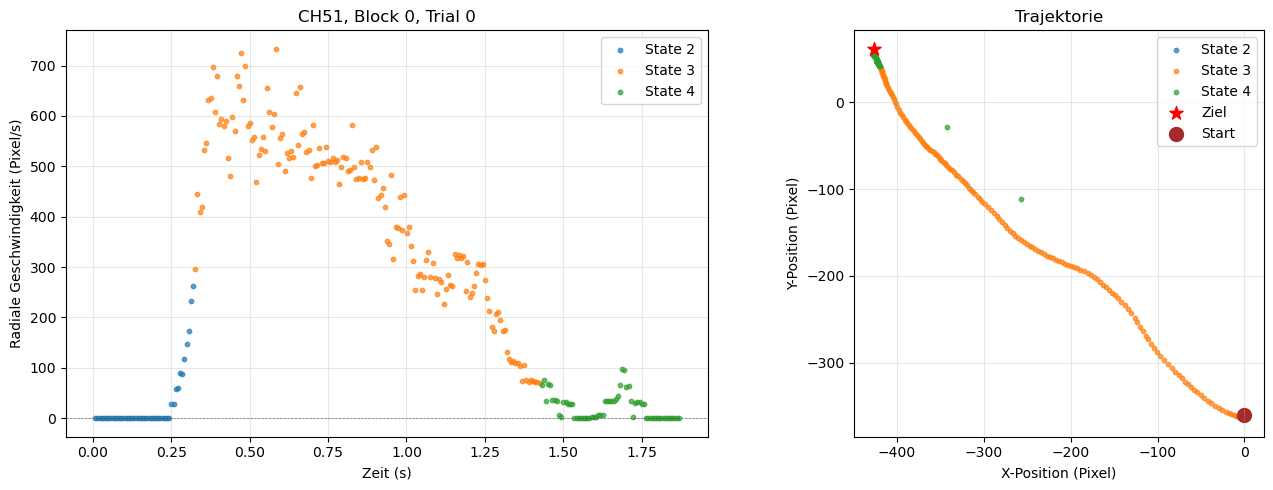


 Statistik für CH51, Block 0, Trial 0:
  Mittlere v_radial: 252.19 Pixel/s
  Maximale v_radial: 733.26 Pixel/s
  Minimale v_radial: 0.00 Pixel/s


In [32]:
# Alle verfügbaren Trials
all_trials = df_reaching_clean[['Participant', 'block', 'trial']].drop_duplicates().sort_values(['Participant', 'block', 'trial']).reset_index(drop=True)
current_idx = 0

def plot_trial(idx):
    row = all_trials.iloc[idx]
    participant = row['Participant']
    block = row['block']
    trial = row['trial']
    
    # Daten filtern
    df_filtered = df_reaching_clean[
        (df_reaching_clean['Participant'] == participant) &
        (df_reaching_clean['block'] == block) &
        (df_reaching_clean['trial'] == trial)
    ]
    
    if df_filtered.empty:
        print(f"Keine Daten für {participant}, Block {block}, Trial {trial}")
        return
    
    # Plot erstellen
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Radiale Geschwindigkeit über Zeit (geglättet)
    for marker in sorted(df_filtered['state_marker'].unique()):
        mask = df_filtered['state_marker'] == marker
        ax1.scatter(
            df_filtered.loc[mask, 'time_rel'], 
            df_filtered.loc[mask, 'v_radial'],
            label=f'State {marker}',
            alpha=0.7,
            s=10
        )
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=0.5)
    ax1.set_xlabel('Zeit (s)')
    ax1.set_ylabel('Radiale Geschwindigkeit (Pixel/s)')
    ax1.set_title(f'{participant}, Block {block}, Trial {trial}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Trajektorie
    for marker in sorted(df_filtered['state_marker'].unique()):
        mask = df_filtered['state_marker'] == marker
        ax2.scatter(
            df_filtered.loc[mask, 'cursor_x_smooth'], 
            df_filtered.loc[mask, 'cursor_y_smooth'],
            label=f'State {marker}',
            alpha=0.7,
            s=10
        )
    ax2.scatter([df_filtered['target_x'].iloc[0]], [df_filtered['target_y'].iloc[0]], 
                color='red', s=100, marker='*', label='Ziel')
    # Fester Startpunkt aus dem Experiment (params.py)
    start_x = 0      # STARTING_POINT_POS[0]
    start_y = -360   # STARTING_POINT_POS[1]
    ax2.scatter([start_x], [start_y], color='brown', s=100, marker='o', label='Start')
    ax2.set_xlabel('X-Position (Pixel)')
    ax2.set_ylabel('Y-Position (Pixel)')
    ax2.set_title('Trajektorie')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    # Statistik anzeigen
    print(f"\n Statistik für {participant}, Block {block}, Trial {trial}:")
    print(f"  Mittlere v_radial: {df_filtered['v_radial'].mean():.2f} Pixel/s")
    print(f"  Maximale v_radial: {df_filtered['v_radial'].max():.2f} Pixel/s")
    print(f"  Minimale v_radial: {df_filtered['v_radial'].min():.2f} Pixel/s")

# Next/Previous Buttons
def next_trial(b):
    global current_idx
    current_idx = min(current_idx + 1, len(all_trials) - 1)
    plot_trial(current_idx)

def prev_trial(b):
    global current_idx
    current_idx = max(current_idx - 1, 0)
    plot_trial(current_idx)

# Dropdowns für Navigation
participant_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean['Participant'].unique()),
    description='Participant:'
)

block_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean['block'].unique()),
    description='Block:'
)

trial_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean[df_reaching_clean['Participant'] == participant_dropdown.value]['trial'].unique()),
    description='Trial:'
)

def update_trials(change):
    block_dropdown.options = sorted(df_reaching_clean[df_reaching_clean['Participant'] == change.new]['block'].unique())
    trial_dropdown.options = sorted(df_reaching_clean[
        (df_reaching_clean['Participant'] == change.new) & 
        (df_reaching_clean['block'] == block_dropdown.value)
    ]['trial'].unique())

participant_dropdown.observe(update_trials, names='value')

def on_go_button(b):
    global current_idx
    mask = (all_trials['Participant'] == participant_dropdown.value) & \
           (all_trials['block'] == block_dropdown.value) & \
           (all_trials['trial'] == trial_dropdown.value)
    if mask.any():
        current_idx = all_trials[mask].index[0]
        plot_trial(current_idx)

# Buttons
prev_btn = widgets.Button(description='◀ Previous')
next_btn = widgets.Button(description='Next ▶')
go_btn = widgets.Button(description='Go', button_style='success')

prev_btn.on_click(prev_trial)
next_btn.on_click(next_trial)
go_btn.on_click(on_go_button)

# Layout
controls = widgets.HBox([
    prev_btn,
    participant_dropdown,
    block_dropdown,
    trial_dropdown,
    go_btn,
    next_btn
])

display(controls)

# Ersten Trial anzeigen
plot_trial(0)

Jetzt nur die Statemarker der direkten Experiments

In [57]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from ipywidgets import widgets

# Alle verfügbaren Trials
all_trials = df_reaching_clean[['Participant', 'block', 'trial']].drop_duplicates().sort_values(['Participant', 'block', 'trial']).reset_index(drop=True)
current_idx = 0

# Container für Ausgabe
output = widgets.Output()

def plot_trial(idx):
    # Vorherigen Plot löschen
    plt.close('all')
    output.clear_output(wait=True)
    
    with output:
        row = all_trials.iloc[idx]
        participant = row['Participant']
        block = row['block']
        trial = row['trial']
        
        # Daten filtern
        df_filtered = df_reaching_clean[
            (df_reaching_clean['Participant'] == participant) &
            (df_reaching_clean['block'] == block) &
            (df_reaching_clean['trial'] == trial)
        ].copy()
        
        # Nur State 2, 3, 4
        df_filtered = df_filtered[df_filtered['state_marker'].isin([2, 3, 4])]
        
        if df_filtered.empty:
            print(f"Keine Daten für {participant}, Block {block}, Trial {trial} (State 2-4)")
            return
        
        # Plot erstellen
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot 1: Radiale Geschwindigkeit
        for marker in sorted(df_filtered['state_marker'].unique()):
            mask = df_filtered['state_marker'] == marker
            ax1.scatter(
                df_filtered.loc[mask, 'time_rel'], 
                df_filtered.loc[mask, 'v_radial'],
                label=f'State {marker}',
                alpha=0.7,
                s=10
            )
        
        # Null-Linie
        ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=0.5)
        
        # Feste Y-Achse: -750 bis max(y) + Puffer
        y_min = -750  # Fester negativer Wert
        y_max = df_filtered['v_radial'].max()
        y_padding = abs(y_max) * 0.2 if y_max > 0 else 100
        ax1.set_ylim(y_min, y_max + y_padding)
        
        ax1.set_xlabel('Zeit (s)')
        ax1.set_ylabel('Radiale Geschwindigkeit (Pixel/s)')
        ax1.set_title(f'{participant}, Block {block}, Trial {trial} (State 2-4)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Trajektorie
        for marker in sorted(df_filtered['state_marker'].unique()):
            mask = df_filtered['state_marker'] == marker
            ax2.scatter(
                df_filtered.loc[mask, 'cursor_x_smooth'], 
                df_filtered.loc[mask, 'cursor_y_smooth'],
                label=f'State {marker}',
                alpha=0.7,
                s=10
            )
        
        # Ziel und Start markieren
        ax2.scatter([df_filtered['target_x'].iloc[0]], [df_filtered['target_y'].iloc[0]], 
                    color='red', s=100, marker='*', label='Ziel')
        # Fester Startpunkt aus dem Experiment (params.py)
        start_x = 0      # STARTING_POINT_POS[0]
        start_y = -360   # STARTING_POINT_POS[1]
        ax2.scatter([start_x], [start_y], color='brown', s=100, marker='o', label='Start')
        
        ax2.set_xlabel('X-Position (Pixel)')
        ax2.set_ylabel('Y-Position (Pixel)')
        ax2.set_title('Trajektorie (State 2-4)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_aspect('equal')
        
        plt.tight_layout()
        plt.show()
        # Umrechnungsfaktor (cm pro Pixel)
        cm_per_pixel = 59.7 / 2560  # SCREEN_WIDTH / RESOLUTION_X

        # Werte in cm/s umrechnen
        mean_cm_s = df_filtered['v_radial'].mean() * cm_per_pixel
        max_cm_s = df_filtered['v_radial'].max() * cm_per_pixel
        min_cm_s = df_filtered['v_radial'].min() * cm_per_pixel
        
        # 📊 Statistik (wird bei jedem Aufruf aktualisiert)
        print(f"\n📊 Statistik für {participant}, Block {block}, Trial {trial} (State 2-4):")
        print(f"  Mittlere v_radial: {df_filtered['v_radial'].mean():.2f} Pixel/s  ({mean_cm_s:.2f} cm/s)")
        print(f"  Maximale v_radial: {df_filtered['v_radial'].max():.2f} Pixel/s  ({max_cm_s:.2f} cm/s)")
        print(f"  Minimale v_radial: {df_filtered['v_radial'].min():.2f} Pixel/s  ({min_cm_s:.2f} cm/s)")
        print(f"  Anzahl Samples: {len(df_filtered)}")

# --- Navigation ---
def next_trial(b):
    global current_idx
    current_idx = min(current_idx + 1, len(all_trials) - 1)
    plot_trial(current_idx)

def prev_trial(b):
    global current_idx
    current_idx = max(current_idx - 1, 0)
    plot_trial(current_idx)

# Dropdowns
participant_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean['Participant'].unique()),
    description='Participant:'
)

block_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean['block'].unique()),
    description='Block:'
)

trial_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean[df_reaching_clean['Participant'] == participant_dropdown.value]['trial'].unique()),
    description='Trial:'
)

def update_trials(change):
    block_dropdown.options = sorted(df_reaching_clean[df_reaching_clean['Participant'] == change.new]['block'].unique())
    trial_dropdown.options = sorted(df_reaching_clean[
        (df_reaching_clean['Participant'] == change.new) & 
        (df_reaching_clean['block'] == block_dropdown.value)
    ]['trial'].unique())

participant_dropdown.observe(update_trials, names='value')

def on_go_button(b):
    global current_idx
    mask = (all_trials['Participant'] == participant_dropdown.value) & \
           (all_trials['block'] == block_dropdown.value) & \
           (all_trials['trial'] == trial_dropdown.value)
    if mask.any():
        current_idx = all_trials[mask].index[0]
        plot_trial(current_idx)

# Buttons
prev_btn = widgets.Button(description='◀ Previous')
next_btn = widgets.Button(description='Next ▶')
go_btn = widgets.Button(description='Go', button_style='success')

prev_btn.on_click(prev_trial)
next_btn.on_click(next_trial)
go_btn.on_click(on_go_button)

# Steuerungsleiste (wird ÜBER dem Graphen angezeigt)
controls = widgets.HBox([
    prev_btn,
    participant_dropdown,
    block_dropdown,
    trial_dropdown,
    go_btn,
    next_btn
])

# Layout: Steuerung oben, Graph unten
display(controls)
display(output)

# Ersten Trial anzeigen
plot_trial(0)

Output()

Velocity graph als line plot

In [34]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from ipywidgets import widgets

# Alle verfügbaren Trials
all_trials = df_reaching_clean[['Participant', 'block', 'trial']].drop_duplicates().sort_values(['Participant', 'block', 'trial']).reset_index(drop=True)
current_idx = 0

# Container für Ausgabe
output = widgets.Output()

def plot_trial(idx):
    # Vorherigen Plot löschen
    plt.close('all')
    output.clear_output(wait=True)
    
    with output:
        row = all_trials.iloc[idx]
        participant = row['Participant']
        block = row['block']
        trial = row['trial']
        
        # Daten filtern
        df_filtered = df_reaching_clean[
            (df_reaching_clean['Participant'] == participant) &
            (df_reaching_clean['block'] == block) &
            (df_reaching_clean['trial'] == trial)
        ].copy()
        
        # Nur State 2, 3, 4
        df_filtered = df_filtered[df_filtered['state_marker'].isin([2, 3, 4])]
        
        if df_filtered.empty:
            print(f"Keine Daten für {participant}, Block {block}, Trial {trial} (State 2-4)")
            return
        
        # Plot erstellen (nur ein Plot)
        fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
        
        # Plot: Radiale Geschwindigkeit (Lineplot)
        ax1.plot(df_filtered['time_rel'], df_filtered['v_radial'], 
                 color='blue', linestyle='-', linewidth=1.5, label='Geschwindigkeit')
        ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=0.5)
        ax1.set_xlabel('Zeit relativ (s)')
        ax1.set_ylabel('Radiale Geschwindigkeit (Pixel/s)')
        ax1.set_title(f'{participant}, Block {block}, Trial {trial} (State 2-4)')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Umrechnungsfaktor (cm pro Pixel)
        cm_per_pixel = 59.7 / 2560

        # Werte in cm/s umrechnen
        mean_cm_s = df_filtered['v_radial'].mean() * cm_per_pixel
        max_cm_s = df_filtered['v_radial'].max() * cm_per_pixel
        min_cm_s = df_filtered['v_radial'].min() * cm_per_pixel
        
        # Statistik
        print(f"\n📊 Statistik für {participant}, Block {block}, Trial {trial} (State 2-4):")
        print(f"  Mittlere v_radial: {df_filtered['v_radial'].mean():.2f} Pixel/s  ({mean_cm_s:.2f} cm/s)")
        print(f"  Maximale v_radial: {df_filtered['v_radial'].max():.2f} Pixel/s  ({max_cm_s:.2f} cm/s)")
        print(f"  Minimale v_radial: {df_filtered['v_radial'].min():.2f} Pixel/s  ({min_cm_s:.2f} cm/s)")
        print(f"  Anzahl Samples: {len(df_filtered)}")

# --- Navigation ---
def next_trial(b):
    global current_idx
    current_idx = min(current_idx + 1, len(all_trials) - 1)
    plot_trial(current_idx)

def prev_trial(b):
    global current_idx
    current_idx = max(current_idx - 1, 0)
    plot_trial(current_idx)

# Dropdowns
participant_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean['Participant'].unique()),
    description='Participant:'
)

block_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean['block'].unique()),
    description='Block:'
)

trial_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean[df_reaching_clean['Participant'] == participant_dropdown.value]['trial'].unique()),
    description='Trial:'
)

def update_trials(change):
    block_dropdown.options = sorted(df_reaching_clean[df_reaching_clean['Participant'] == change.new]['block'].unique())
    trial_dropdown.options = sorted(df_reaching_clean[
        (df_reaching_clean['Participant'] == change.new) & 
        (df_reaching_clean['block'] == block_dropdown.value)
    ]['trial'].unique())

participant_dropdown.observe(update_trials, names='value')

def on_go_button(b):
    global current_idx
    mask = (all_trials['Participant'] == participant_dropdown.value) & \
           (all_trials['block'] == block_dropdown.value) & \
           (all_trials['trial'] == trial_dropdown.value)
    if mask.any():
        current_idx = all_trials[mask].index[0]
        plot_trial(current_idx)

# Buttons
prev_btn = widgets.Button(description='◀ Previous')
next_btn = widgets.Button(description='Next ▶')
go_btn = widgets.Button(description='Go', button_style='success')

prev_btn.on_click(prev_trial)
next_btn.on_click(next_trial)
go_btn.on_click(on_go_button)

# Steuerungsleiste
controls = widgets.HBox([
    prev_btn,
    participant_dropdown,
    block_dropdown,
    trial_dropdown,
    go_btn,
    next_btn
])

# Layout: Steuerung oben, Graph unten
display(controls)
display(output)

# Ersten Trial anzeigen
plot_trial(0)

Output()

Tabelle mit den werten:

In [59]:
import pandas as pd
import numpy as np
from pathlib import Path

metrics_list = []

for (participant, trial, block), group in df_reaching_clean.groupby(['Participant', 'trial', 'block']):
    try:
        # Relative Zeit für den GESAMTEN Trial
        time_rel_full = group['time'] - group['time'].iloc[0]
        
        # Nur State 2-4 für Metriken
        group_motion = group[group['state_marker'].isin([2, 3, 4])].copy()
        blob_width = group['blob_width'].iloc[0]
        
        # Standardwerte
        latency = peak = duration = quick_phase = slow_phase = pos_error = precision = np.nan
        
        if not group_motion.empty:
            # Relative Zeit für State 2-4 (basierend auf Trial-Beginn)
            time_rel = group_motion['time'] - group['time'].iloc[0]  # <-- HIER GEÄNDERT
            
            # Latenz
            mask = group_motion['v_radial'].fillna(0) > 10
            if mask.any():
                latency = time_rel[mask].iloc[0]
                t0 = latency
                t_peak = time_rel[group_motion['v_radial'].idxmax()]
                first_state4 = group_motion[group_motion['state_marker'] == 4].iloc[0]
                t_end = time_rel[first_state4.name]  # Zeitpunkt des ersten Frames in State 4
                duration = t_end - t0
                quick_phase = t_peak - t0
                slow_phase = t_end - t_peak
            else:
                latency = duration = quick_phase = slow_phase = np.nan
            
            # Peak velocity
            peak = group_motion['v_radial'].max()
            
            # Position error
            last = group_motion.iloc[-1]
            target_x = group_motion['target_x'].iloc[0]
            target_y = group_motion['target_y'].iloc[0]
            pos_error = np.sqrt((last['cursor_x_smooth'] - target_x)**2 +
                                (last['cursor_y_smooth'] - target_y)**2)
            
            # Precision (State 4)
            df_state4 = group_motion[group_motion['state_marker'] == 4]
            if len(df_state4) > 5:
                precision = np.std(df_state4['cursor_x_smooth'])**2 + np.std(df_state4['cursor_y_smooth'])**2
            else:
                precision = np.nan
    except Exception as e:
        print(f"Fehler bei {participant}, Block {block}, Trial {trial}: {e}")
        blob_width = group['blob_width'].iloc[0]
        latency = peak = duration = quick_phase = slow_phase = pos_error = precision = np.nan
    
    metrics_list.append({
        'Participant': participant,
        'trial': trial,
        'block': block,
        'blob_width': blob_width,
        'latency_cursor': latency,
        'peak_velocity_cursor': peak,
        'duration_cursor': duration,
        'quick_phase_cursor': quick_phase,
        'slow_phase_cursor': slow_phase,
        'position_error_cursor': pos_error,
        'precision_cursor': precision,
    })

df_metrics_all = pd.DataFrame(metrics_list)

df_metrics_all = pd.DataFrame(metrics_list)
print(df_metrics_all.groupby('blob_width').size())

# DataFrame erstellen
df_metrics_all = pd.DataFrame(metrics_list)

# Anzahl Trials pro blob_width anzeigen
print("Anzahl Trials pro blob_width:")
print(df_metrics_all.groupby('blob_width').size())

# Aggregation
metric_cols = [col for col in df_metrics_all.columns 
               if col not in ['Participant', 'block', 'trial', 'blob_width']]

df_agg = df_metrics_all.groupby('blob_width')[metric_cols].agg(['mean', 'std'])
df_agg.columns = ['_'.join(col).strip() for col in df_agg.columns.values]

# Ausgabe als CSV
output_dir = Path("metrics_output")
output_dir.mkdir(exist_ok=True)

df_agg.to_csv(output_dir / "metrics_by_blobwidth.csv")
df_metrics_all.to_csv(output_dir / "trial_metrics_raw.csv", index=False)

print("\n--- Aggregierte Metriken pro Blob-Width ---")
from IPython.display import display
display(df_agg.round(2))

blob_width
0.15    120
0.30    120
0.45    120
0.60    120
dtype: int64
Anzahl Trials pro blob_width:
blob_width
0.15    120
0.30    120
0.45    120
0.60    120
dtype: int64

--- Aggregierte Metriken pro Blob-Width ---


,latency_cursor_mean,latency_cursor_std,peak_velocity_cursor_mean,peak_velocity_cursor_std,duration_cursor_mean,duration_cursor_std,quick_phase_cursor_mean,quick_phase_cursor_std,slow_phase_cursor_mean,slow_phase_cursor_std,position_error_cursor_mean,position_error_cursor_std,precision_cursor_mean,precision_cursor_std
blob_width,,,,,,,,,,,,,,
0.15,0.23,0.11,1555.16,411.52,0.78,0.20,0.33,0.16,0.44,0.16,240.15,2.77,1149.59,239.36
0.30,0.30,0.22,1067.89,642.56,0.67,0.26,0.37,0.26,0.30,0.27,240.46,3.73,1110.35,150.83
0.45,0.27,0.22,1121.76,622.99,0.65,0.25,0.32,0.21,0.33,0.25,240.79,3.76,1116.58,90.19
0.60,0.29,0.18,1148.76,592.55,0.63,0.21,0.28,0.14,0.35,0.16,7.60,3.59,201.49,73.34


In [60]:
# CSV exportieren (falls nicht schon geschehen)
output_dir = Path("metrics_output")
output_dir.mkdir(exist_ok=True)

df_agg.to_csv(output_dir / "metrics_by_blobwidth.csv")
df_metrics_all.to_csv(output_dir / "trial_metrics_raw.csv", index=False)

print("CSV-Dateien gespeichert in:", output_dir.absolute())

CSV-Dateien gespeichert in: c:\Users\march\Desktop\Studium\Viertes Semester\Experimental Praktikum\ExPra2026_analysis\metrics_output


In [61]:
# Aggregation pro Participant und Blob‑Width
# ------------------------------------------------------------
# Gruppiere nach Participant und blob_width
# Berechne Mittelwert und Standardabweichung für alle metrischen Spalten

# Metrik-Spalten (ohne Identifikatoren)
metric_cols = [col for col in df_metrics_all.columns 
               if col not in ['Participant', 'block', 'trial', 'blob_width']]

# Aggregation: mean und std
df_participant_blob_agg = df_metrics_all.groupby(['Participant', 'blob_width'])[metric_cols].agg(['mean', 'std'])

# Spalten umbenennen: z.B. 'latency_cursor_mean', 'latency_cursor_std'
df_participant_blob_agg.columns = ['_'.join(col).strip() for col in df_participant_blob_agg.columns.values]

# Zurücksetzen des Index, damit Participant und blob_width als Spalten erscheinen
df_participant_blob_agg = df_participant_blob_agg.reset_index()

# ------------------------------------------------------------
# Ausgabe als CSV
# ------------------------------------------------------------
output_dir = Path("metrics_output")
output_dir.mkdir(exist_ok=True)

df_participant_blob_agg.to_csv(output_dir / "metrics_by_participant_blobwidth.csv", index=False)
print(f"Gespeichert: {output_dir / 'metrics_by_participant_blobwidth.csv'}")

# ------------------------------------------------------------
# Anzeige der Tabelle (alle Zeilen)
# ------------------------------------------------------------
from IPython.display import display
print("\n--- Metriken pro Participant und Blob-Width ---")
display(df_participant_blob_agg.round(2))

Gespeichert: metrics_output\metrics_by_participant_blobwidth.csv

--- Metriken pro Participant und Blob-Width ---


,Participant,blob_width,latency_cursor_mean,latency_cursor_std,peak_velocity_cursor_mean,peak_velocity_cursor_std,duration_cursor_mean,duration_cursor_std,quick_phase_cursor_mean,quick_phase_cursor_std,slow_phase_cursor_mean,slow_phase_cursor_std,position_error_cursor_mean,position_error_cursor_std,precision_cursor_mean,precision_cursor_std
0,CH51,0.15,0.22,0.10,1283.68,532.42,0.68,0.18,0.21,0.12,0.47,0.14,240.68,2.79,1081.57,85.02
1,CH51,0.30,0.41,0.33,641.50,755.18,0.42,0.34,0.27,0.29,0.15,0.28,241.19,4.34,1081.06,65.74
2,CH51,0.45,0.32,0.26,727.18,717.97,0.48,0.26,0.30,0.32,0.18,0.36,240.82,3.59,1104.60,55.38
3,CH51,0.60,0.30,0.22,776.59,666.77,0.51,0.25,0.21,0.12,0.30,0.23,7.95,3.36,193.36,69.93
4,IR31,0.15,0.31,0.11,1801.15,177.56,0.73,0.16,0.34,0.13,0.39,0.09,239.95,1.98,1175.75,321.59
5,IR31,0.30,0.44,0.15,1388.94,498.74,0.64,0.18,0.34,0.13,0.29,0.21,240.32,2.09,1100.00,70.37
6,IR31,0.45,0.37,0.17,1335.52,603.08,0.59,0.22,0.28,0.19,0.31,0.19,240.81,2.50,1128.32,84.32
7,IR31,0.60,0.39,0.13,1365.51,502.05,0.63,0.14,0.30,0.13,0.32,0.14,5.69,2.35,210.24,57.42
8,LJ25,0.15,0.21,0.09,1402.17,202.05,0.88,0.19,0.44,0.13,0.44,0.16,239.16,2.03,1132.73,167.53
9,LJ25,0.30,0.18,0.10,1100.25,491.74,0.80,0.13,0.47,0.26,0.33,0.26,240.08,3.33,1154.46,251.40


# Continuous Tracking

# Creating Data Frame

In [ ]:
# 1. Den Hauptordner definieren (das 'r' vor dem String ist wichtig für Windows-Pfade, damit Backslashes nicht als Steuerzeichen gelesen werden)
basis_ordner = Path("data/Continuous_tracking")

# Eine leere Liste, in der wir alle einzelnen Datensätze sammeln
alle_dfs = []

# 2. Automatisch alle CSV-Dateien suchen
# .rglob("*.csv") sucht rekursiv (also im Hauptordner UND in allen Unterordnern) nach CSV-Dateien
for datei_pfad in basis_ordner.rglob("*.csv"):
    
    # 3. CSV einlesen
    df_temp = pd.read_csv(datei_pfad)
    
    # WICHTIG: Probanden-ID aus dem Dateipfad extrahieren und als Spalte anfügen.
    # datei_pfad.parent.name gibt uns genau den Namen des Unterordners (z.B. 'ch51' oder 'ir31')
    df_temp['Participant'] = datei_pfad.parent.name
    
    # Den markierten DataFrame in unsere Liste packen
    alle_dfs.append(df_temp)

# 4. Alle Datensätze aus der Liste zu einem großen Master-DataFrame zusammenführen
# ignore_index=True sorgt dafür, dass die Zeilen von 0 bis X durchgehend neu nummeriert werden
df_tracking = pd.concat(alle_dfs, ignore_index=True)

# 5. Daten inspizieren
print(df_tracking.head())
print("\n" + "="*50 + "\n") # Nur ein optischer Trennstrich
print(df_tracking.info())

   target_width  cursor-width  target_pos_x  target_pos_y  cursor_pos_x  \
0           0.1           0.0           0.0           0.0      0.239135   
1           0.1           0.0           0.0           0.0      0.239135   
2           0.1           0.0           0.0           0.0      0.211002   
3           0.1           0.0           0.0           0.0      0.196935   
4           0.1           0.0           0.0           0.0      0.182868   

   cursor_pos_y  target_vel_x  target_vel_y  timestamp  trial_number  \
0      0.014067           0.0           0.0   0.000008             0   
1      0.014067           0.0           0.0   0.006560             0   
2      0.000000           0.0           0.0   0.012574             0   
3     -0.014067           0.0           0.0   0.019620             0   
4     -0.028134           0.0           0.0   0.027063             0   

   training  gaze_pos_x  gaze_pos_y  tracker_time  state_marker Participant  
0      True   33.900024   11.900024   

# Cleaning the data

In [ ]:
# Wir filtern den Master-DataFrame und speichern das Ergebnis in einer neuen Variable
# Wichtig: Bei Booleans (True/False) schreiben wir False ohne Anführungszeichen!
df_continuous_clean = df_tracking[df_tracking['training'] == False]

# Ein kurzer Check, um sicherzugehen, dass das Filtern geklappt hat:
# .unique() sollte uns jetzt nur noch [False] ausgeben.
print("Verbleibende Werte in der 'training' Spalte:")
print(df_continuous_clean['training'].unique())

# Optional: Schauen wir, wie viele Zeilen wir vorher und nachher haben
print(f"Zeilen vorher: {len(df_tracking)}")
print(f"Zeilen nachher: {len(df_continuous_clean)}")

Verbleibende Werte in der 'training' Spalte:
[False]
Zeilen vorher: 491512
Zeilen nachher: 472480


In [ ]:
# 1. Chronologisch ordnen
df_continuous_clean = df_continuous_clean.sort_values(by=['Participant', 'trial_number', 'timestamp'])

# 2. Differenzen berechnen
df_continuous_clean['dt'] = df_continuous_clean.groupby(['Participant', 'trial_number'])['timestamp'].diff()
df_continuous_clean['dx'] = df_continuous_clean.groupby(['Participant', 'trial_number'])['cursor_pos_x'].diff()
df_continuous_clean['dy'] = df_continuous_clean.groupby(['Participant', 'trial_number'])['cursor_pos_y'].diff()

# 3. Pythagoras für Distanz
df_continuous_clean['dist'] = np.sqrt(df_continuous_clean['dx']**2 + df_continuous_clean['dy']**2)

# 4. Geschwindigkeit
df_continuous_clean['cursor_velocity'] = df_continuous_clean['dist'] / df_continuous_clean['dt']

# Kurzer Check
print(df_continuous_clean[['timestamp', 'cursor_pos_x', 'cursor_velocity']].head())

      timestamp  cursor_pos_x  cursor_velocity
4758   0.000008      0.056267              NaN
4759   0.006598      0.056267         0.000000
4760   0.013598      0.056267         2.009618
4761   0.020558      0.056267         2.021184
4762   0.027585      0.042200         2.831132
